# Лабораторная работа № 2. Исследовательский анализ данных

**Цель работы:**

Изучение связи между признаками жвумерного набора данных, визуализация данных.

 # Загрузка набора данных

Вариант № 14

Набор данных: clients.csv

Атрибуты:
1. уникальный идентификатор клиента
2. год рождения клиента
3. уровень образования клиента
4. семейное положение клиента
5. годовой доход семьи
6. количестве детей
7. дата регистрации клиента в компании
8. количество покупок

# Что нужно сделать

1. Загрузка и первичный анализ данных. Предварительная обработка.
2. Построить точечную диаграмму для всех признаков. Выполнить анализ результата.
3. Построить гистограмму для каждого числового признака, подобрать оптимальное количество bins. Сделать выводы.
4. Корреляция, ковариация и тепловая карта.
5. Задания варианта 14.
6. Hexagonal binning plot.
7. Boxplot.
8. Добавление категории.
9. Дополнительные boxplot по категориальным признакам.
10. Общие выводы.

## 1. Импорт и оценка датасета

In [64]:
import pandas as pd
df = pd.read_csv(r'C:\Users\pupul\Downloads\clients.csv', sep=';')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 796 non-null    int64  
 1   Year_Birth         796 non-null    int64  
 2   Education          796 non-null    object 
 3   Marital_Status     796 non-null    object 
 4   Income             784 non-null    float64
 5   Kidhome            795 non-null    float64
 6   Dt_Customer        795 non-null    object 
 7   NumDealsPurchases  795 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 49.9+ KB


,ID,Year_Birth,Income,Kidhome,NumDealsPurchases
count,796.000000,796.000000,784.00000,795.000000,795.000000
mean,5630.133166,1968.356784,53130.07398,0.438994,2.314465
std,3273.039715,12.022132,21818.56876,0.547252,1.941650
min,0.000000,1899.000000,2447.00000,0.000000,0.000000
25%,2853.000000,1959.000000,36141.75000,0.000000,1.000000
50%,5563.000000,1969.500000,52372.50000,0.000000,2.000000
75%,8584.250000,1977.000000,69293.25000,1.000000,3.000000
max,11191.000000,1995.000000,162397.00000,2.000000,15.000000


После успешной загрузки файла данные преобразовались в датафрейм - двумерную структуру данных в pandas, которая имеет две координаты: строка и столбец. 

Информация о данных , полученная с помощью info() и  describe() показала, что в 4 столбцах таблицы есть минимум 1 пропуск (всего 15), и 3 столбца имеют некорректный тип данных.

Названия столбцов написаны верно. Так как критических проблем не было обнарудено, они не будут переименованы. 

In [3]:
print(df.isna().sum())

df['Income'] = df['Income'].fillna(df['Income'].median())
df['Kidhome'] = df['Kidhome'].fillna(df['Kidhome'].median())
df['Dt_Customer'] = df['Dt_Customer'].fillna(df['Dt_Customer'].mode()[0])
df['NumDealsPurchases'] = df['NumDealsPurchases'].fillna(df['NumDealsPurchases'].median())

print(df.isna().sum())

ID                    0
Year_Birth            0
Education             0
Marital_Status        0
Income               12
Kidhome               1
Dt_Customer           1
NumDealsPurchases     1
dtype: int64
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Dt_Customer          0
NumDealsPurchases    0
dtype: int64


В процессе предобработки данных были заполнены 15 пропусков. Количественные  - медианным значением, дата заполнена модой. После обработки осталось 0 пропусков.

In [4]:
print(df.duplicated().sum())

# удалиение явных дубликатов
df = df.drop_duplicates().reset_index(drop=True)
print(df.duplicated().sum())

print('Уникальные значения Education')
print(df['Education'].unique())
print()
print('Уникальные значения Marital_Status')
print(df['Marital_Status'].unique())

# удаление невявных дубликатов
df['Marital_Status'] = df['Marital_Status'].replace('MARRIED', 'Married')
df['Marital_Status'] = df['Marital_Status'].replace('SINGL', 'Single')

print('Уникальные значения Education')
print(df['Education'].unique())
print()
print('Уникальные значения Marital_Status')
print(df['Marital_Status'].unique())

4
0
Уникальные значения Education
['Graduation' 'PhD' 'Master' 'Basic']

Уникальные значения Marital_Status
['Single' 'Together' 'Married' 'Divorced' 'MARRIED' 'SINGL' 'Widow'
 'Alone']
Уникальные значения Education
['Graduation' 'PhD' 'Master' 'Basic']

Уникальные значения Marital_Status
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone']


Данные были проверены на дубликаты. Были обнаружены и явные, и неявные образцы. Они были успешно удалены.

In [5]:
df['Kidhome'] = df['Kidhome'].astype(int)
df['NumDealsPurchases'] = df['NumDealsPurchases'].astype(int)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d.%m.%Y')

df.dtypes

ID                            int64
Year_Birth                    int64
Education                    object
Marital_Status               object
Income                      float64
Kidhome                       int64
Dt_Customer          datetime64[ns]
NumDealsPurchases             int64
dtype: object

Некорректные типы данных также были изменены. Теперь датасет готов к юальнейшей работе.

## 2. Матрица диаграмм рессеивания

Матрица диаграмм рассеяния позволяет одновременно изучить попарные взаимосвязи между количественными признаками. ID исключается, поскольку это идентификатор, а категориальные признаки не имеют непосредственного числового смысла для scatter matrix.

Для количественных признаков рассматриваются:
- год рождения;
- годовой доход;
- количество детей;
- количество покупок.

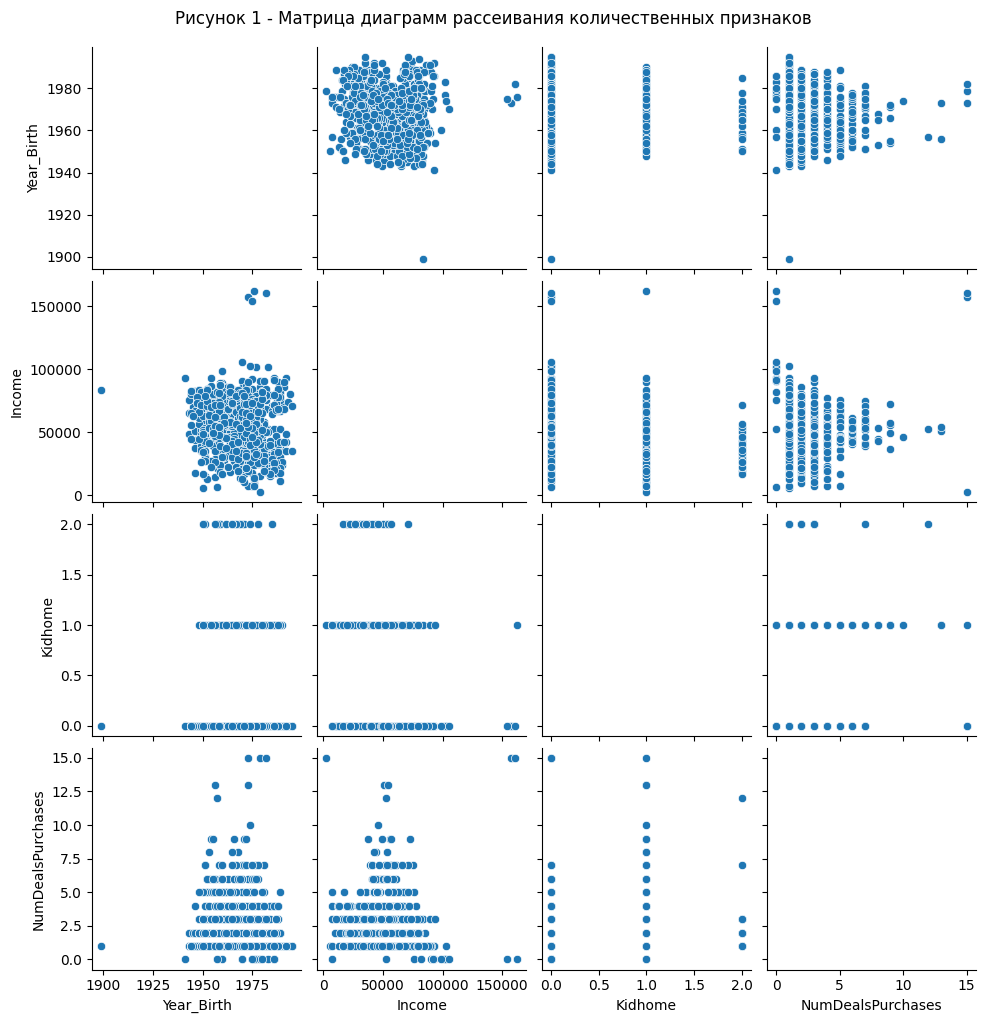

In [18]:
import matplotlib.pyplot as plt
numeric_cols = ["Year_Birth", "Income", "Kidhome", "NumDealsPurchases"]

sns.pairplot(df[numeric_cols], diag_kind='dge')
plt.suptitle('Рисунок 1 - Матрица диаграмм рассеивания количественных признаков', y=1.02)
plt.show()

Из рисунка видно, что между показателями отсутствует линейная зависимость. В основном полученные диаграммы отображают только характеристики выборки (преимущественно какой доход имеют люди, сколько им лет и так далее).


**Матрица с выделением категорий образования**

Дополнительно используется seaborn.pairplot, где цвет точек соответствует уровню образования. Это позволяет оценить, различается ли распределение количественных признаков между образовательными группами.

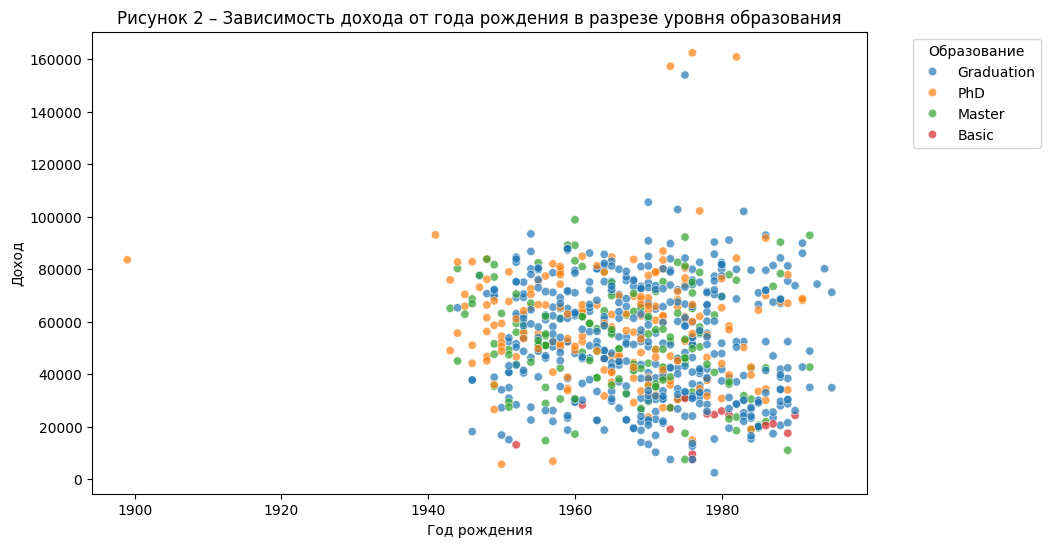

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Year_Birth', y='Income', hue='Education', alpha=0.7)
plt.title('Рисунок 2 – Зависимость дохода от года рождения в разрезе уровня образования')
plt.xlabel('Год рождения')
plt.ylabel('Доход')
plt.legend(title='Образование', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Из рисунка 2 видно, что клиенты с ученой степенью (PhD, Master) в среднем имеют более высокий доход. При этом разброс доходов достаточно большой во всех представленных группах. 

## 3. Гистограммы

Гистограммы позволяют изучить распределения отдельных количественных признаков.
Для дискретных признаков с небольшим количеством уникальных значений используется число интервалов, соответствующее наблюдаемым значениям.

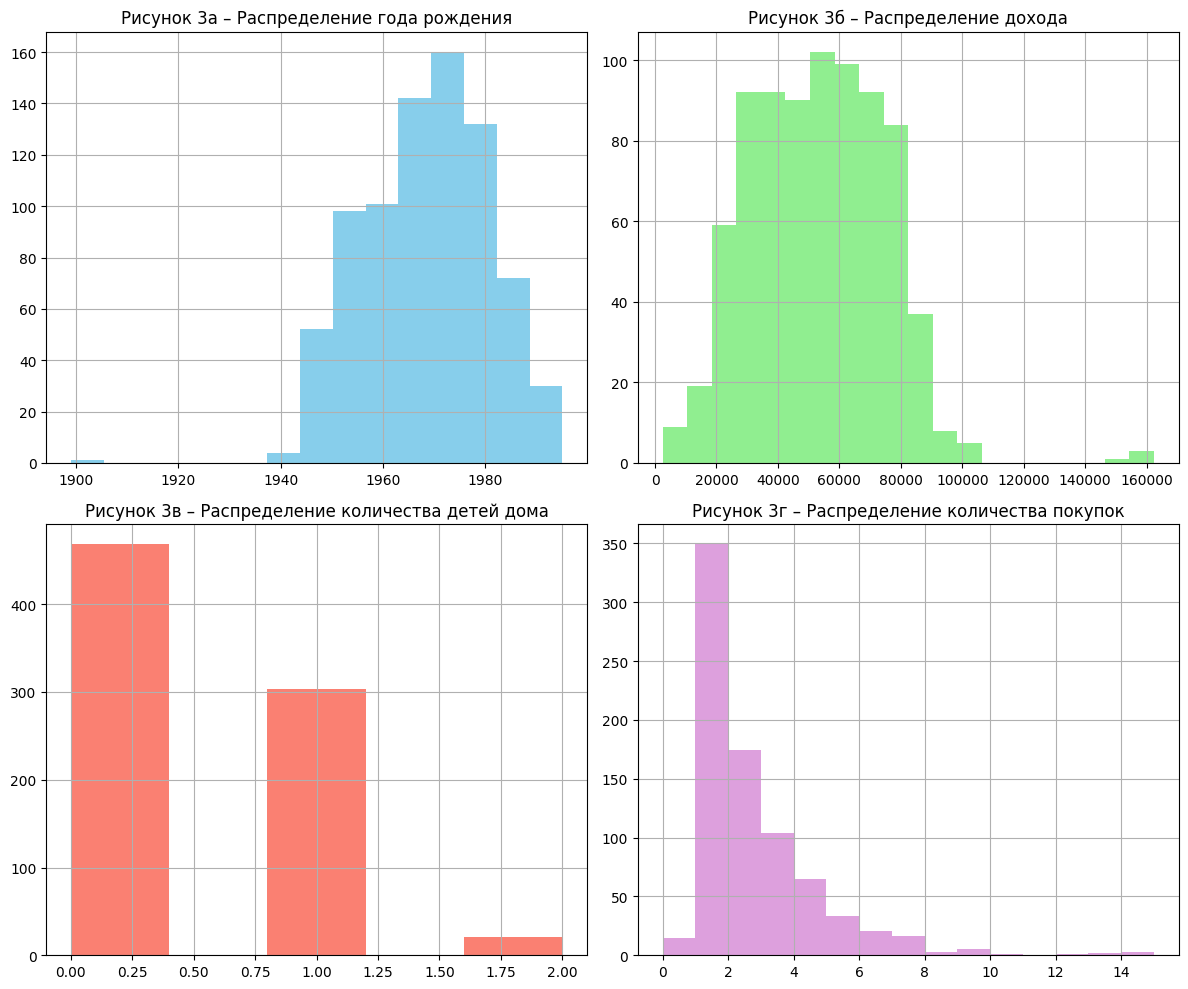

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df['Year_Birth'].hist(bins=15, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Рисунок 3а – Распределение года рождения')

df['Income'].hist(bins=20, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Рисунок 3б – Распределение дохода')

df['Kidhome'].hist(bins=5, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Рисунок 3в – Распределение количества детей дома')

df['NumDealsPurchases'].hist(bins=15, ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Рисунок 3г – Распределение количества покупок')

plt.tight_layout()
plt.show()

Для построения гистограмм количество интервалов (bins) было подобрано отдельно для каждого количественного признака с учётом диапазона и характера его значений. 

Для Year_Birth выбрано 15 интервалов, так как признак имеет достаточно широкий диапазон, и такое количество позволяет увидеть распределение годов рождения без чрезмерного дробления. Для Income выбрано 20 интервалов из-за большого диапазона значений дохода — большее число интервалов позволяет подробнее рассмотреть форму распределения и его неоднородность. Для Kidhome выбрано 5 интервалов, так как признак принимает небольшое количество дискретных значений, поэтому большое количество интервалов было бы избыточным. Для NumDealsPurchases выбрано 15 интервалов, поскольку этот признак также является дискретным, но имеет более широкий диапазон значений, чем Kidhome, поэтому 15 интервалов позволяют сохранить детализацию распределения.

3а: Год рождения сосредоточен в основном в диапазоне нескольких десятилетий. Есть аномальное значение 1899 года рождения. Без него распределение близко к нормальному.

3б: Доход имеет достоаточный разброс и правый хвост - наличие клиентов с более высоким доходом (Правосторонняя ассиметрия).

3в: У большей части клиентов нет детей. Немного меньше людей имеют по 1 ребенку и единицы по 2. 

3г: В основном принимает небольшие значения. Высокие встречаются редко.

## 4. Корреляция, ковариация и тепловая карта


Коэффициент корреляции Пирсона оценивает направление и силу линейной связи. Его значение находится от -1 до 1.

Ковариация показывает совместное изменение признаков, но, в отличие от корреляции, зависит от единиц измерения, поэтому абсолютные значения ковариации нельзя напрямую сравнивать между признаками разных масштабов.

Матрица корреляции: 
                    Year_Birth    Income   Kidhome  NumDealsPurchases
Year_Birth           1.000000 -0.142735  0.244132          -0.060943
Income              -0.142735  1.000000 -0.528154          -0.053562
Kidhome              0.244132 -0.528154  1.000000           0.198518
NumDealsPurchases   -0.060943 -0.053562  0.198518           1.000000

Матрица ковариации: 
                      Year_Birth        Income      Kidhome  NumDealsPurchases
Year_Birth           144.573548 -3.725570e+04     1.605812          -1.425404
Income            -37255.699019  4.712346e+08 -6271.976325       -2261.745527
Kidhome                1.605812 -6.271976e+03     0.299262           0.211250
NumDealsPurchases     -1.425404 -2.261746e+03     0.211250           3.783926


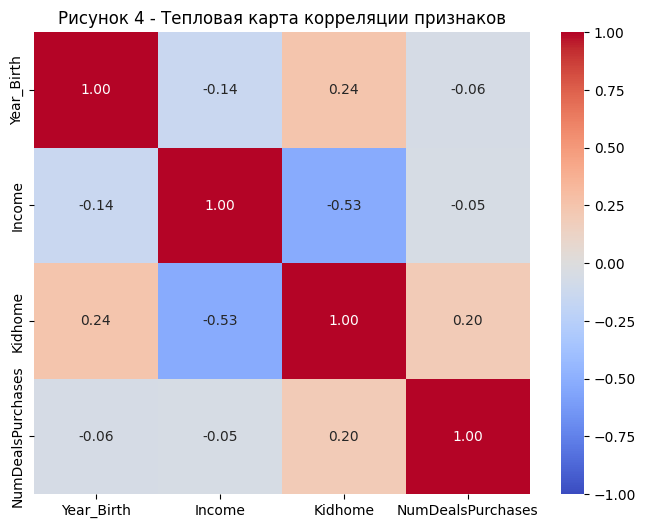

In [26]:
corr_matrix = df[numeric_cols].corr()
print("Матрица корреляции: \n", corr_matrix)
print("\nМатрица ковариации: \n", df[numeric_cols].cov())
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Рисунок 4 - Тепловая карта корреляции признаков')
plt.show()

Наибольшая по модулю корреляция наблюдается между доходом и количеством детей (-0.53). То есть в среднем большее количество детей есть у людей с более низким доходом. Но это нельзя выделить как причину, так как корреляция не позволяет простроить причинно-следственную связь.

Ковариация между доходом и количеством детей отрицательная, а между количеством детей и количеством покупок положительная, что согласуется с направлением соответствующих коэффициентов корреляции. При этом величина ковариации напрямую зависит от единиц измерения, поэтому для сравнения силы связей предпочтительнее корреляция.

## 5. Задания варианта 14

### Задание 1: Использовать seaborn


По группировке - тип образования и количество клиентов по каждому семейному статусу (marital_status) построить диаграмму следующего вида: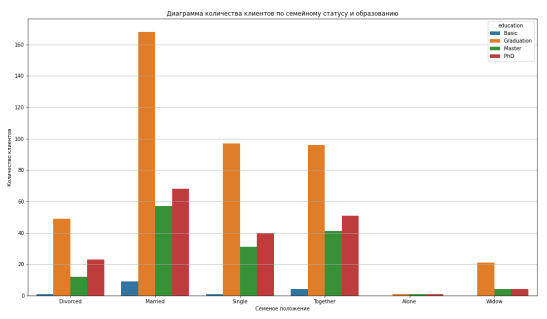.

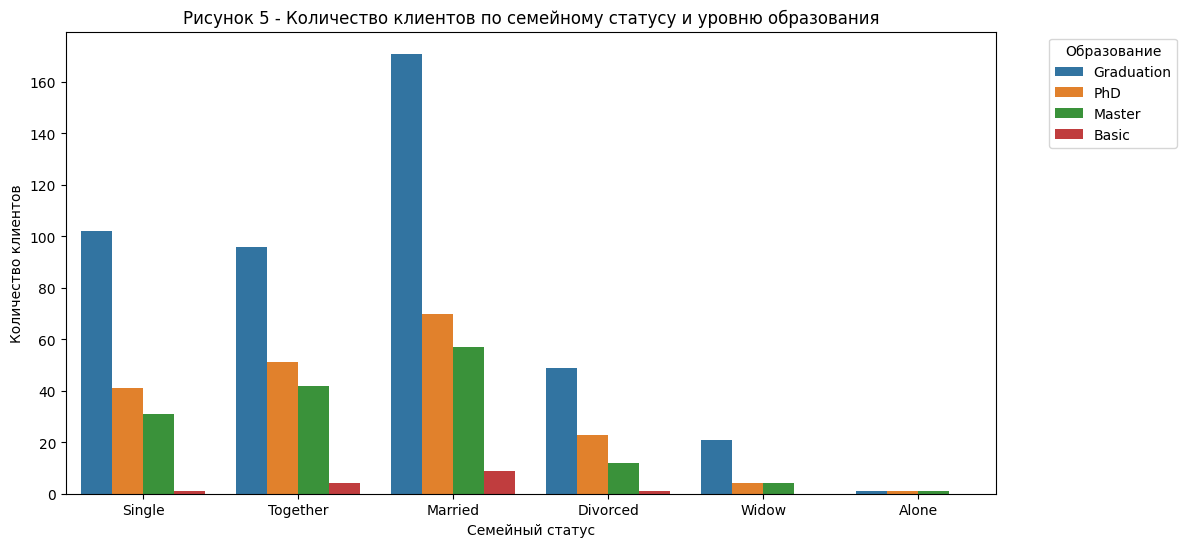

In [62]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Marital_Status', hue='Education')
plt.title('Рисунок 5 - Количество клиентов по семейному статусу и уровню образования')
plt.xlabel('Семейный статус')
plt.ylabel('Количество клиентов')
plt.legend(title='Образование', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

На диаграмме представлено распределение клиентов по уровню образования для различных семейных статусов. По оси X расположены категории семейного статуса, цветом выделены уровни образования, а высота столбцов соответствует количеству клиентов в каждой категории. Наибольшее количество клиентов относится к уровню образования Graduation. Среди семейных статусов наиболее многочисленными являются Married, Together и Single. Для менее многочисленных категорий, таких как Widow и Alone, количество наблюдений значительно меньше.

### Задание 2: Использовать pandas и plot

По сводной таблице (pivot_table) - отобразить средний доход семьи по семейному положению. Отобразить маркеры в виде ★ розового (deeppink) цвета размером 20.


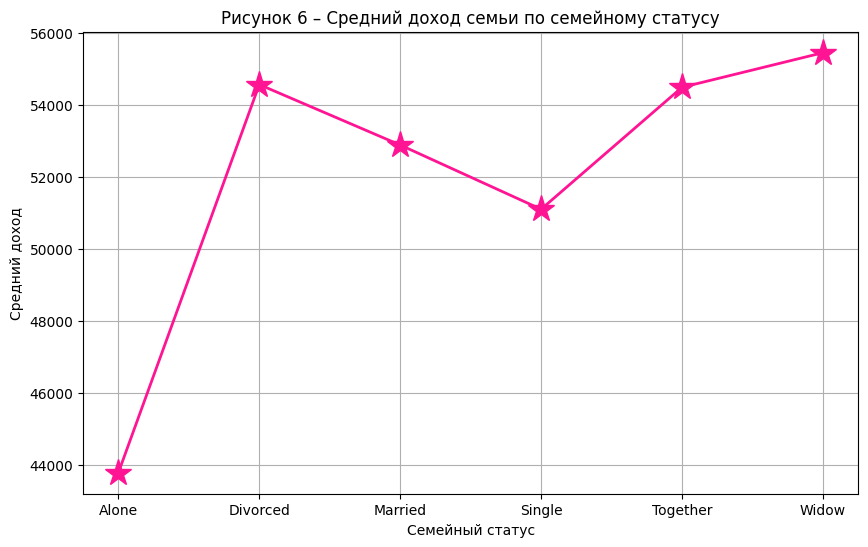

In [31]:
pivot_income = df.pivot_table(values='Income', index='Marital_Status', aggfunc='mean').reset_index()
plt.figure(figsize=(10, 6))
plt.plot(pivot_income['Marital_Status'], pivot_income['Income'], 
         marker='*', color='deeppink', markersize=20, linewidth=2)
plt.title('Рисунок 6 – Средний доход семьи по семейному статусу')
plt.xlabel('Семейный статус')
plt.ylabel('Средний доход')
plt.grid(True)
plt.show()

Самый высокий средний доход в выборке приходится на категорию вдовцов, дальше следуют разведенные и пары не в оф. браке. Наименьшее среднее значение наблюдается у одиноких, но эта категория содержит всего несколько наблюдений, поэтому её нельзя считать устойчивой представительской группой.

Средний доход категорий женатые, свободные и пары не в оф. браке отличается умеренно. Семейное положение связано с уровнем дохода, но не определяет его однозначно.

### Задание 3: Использовать matplotlib

Отфильтровать клиентов по количеству детей больше 0. Построить круговую диаграмму, которая отображает процент клиентов определенного уровня образования.


После фильтрации осталось: 328


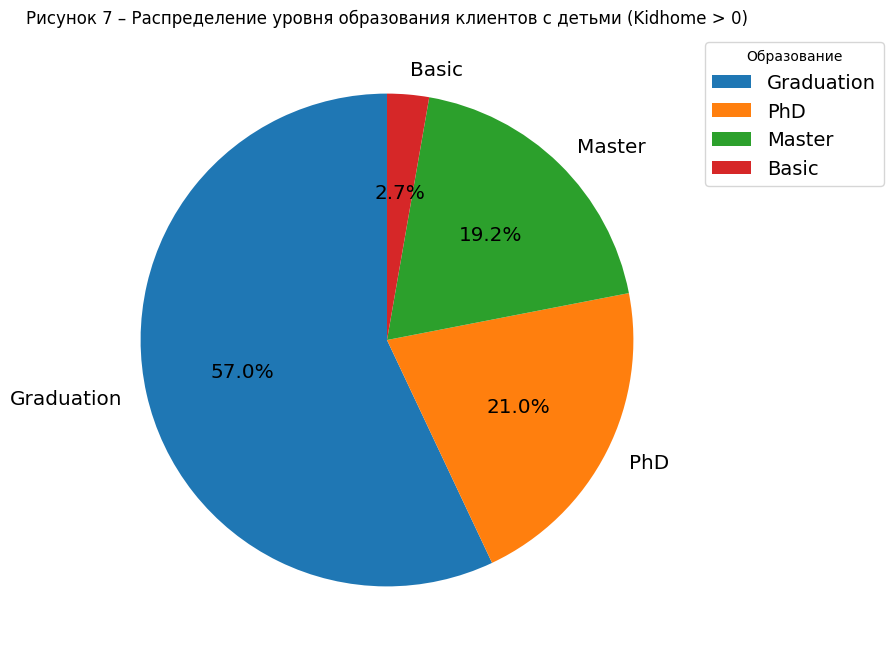

In [68]:
df_kids = df[df['Kidhome'] > 0]
edu_counts = df_kids['Education'].value_counts()
print('После фильтрации осталось:', sum(edu_counts))
plt.figure(figsize=(8, 8))
plt.pie(edu_counts, labels=edu_counts.index, autopct='%.1f%%', 
        textprops={'size': 'x-large'}, startangle=90)
plt.title('Рисунок 7 – Распределение уровня образования клиентов с детьми (Kidhome > 0)')
plt.legend(title='Образование', fontsize=14, bbox_to_anchor=(1, 1))
plt.show()

После фильтрации в выборке осталось 328 клиентов.

Среди клиентов, у которых есть дети, преобладают представители категории Graduation — около 56.5% выборки. Далее идут PhD и Master, а клиенты с уровнем Basic составляют небольшую долю.

Среди клиентов с детьми структура образования в основном определяется категорией Graduation.

## 6. Hexagonal binning plot

Hexagonal binning используется для отображения плотности точек. В данном исследовании он применяется к годовому доходу и году рождения. Более насыщенные области соответствуют участкам, где наблюдается больше клиентов.

<Figure size 800x600 with 0 Axes>

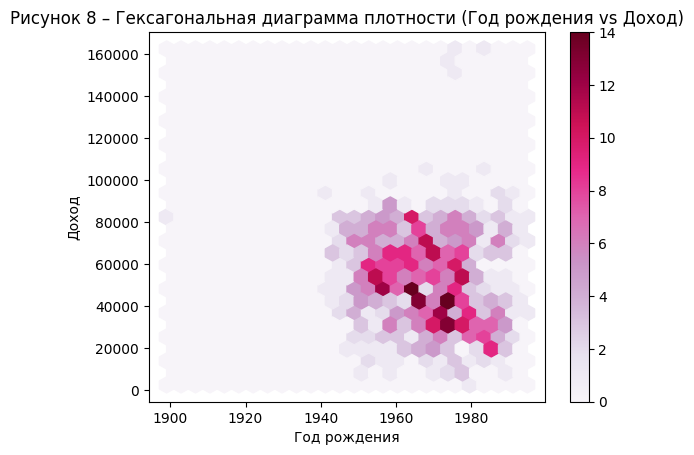

In [39]:
plt.figure(figsize=(8, 6))
df.plot(kind='hexbin', x='Year_Birth', y='Income', gridsize=25, cmap='PuRd')
plt.title('Рисунок 8 – Гексагональная диаграмма плотности (Год рождения vs Доход)')
plt.xlabel('Год рождения')
plt.ylabel('Доход')

plt.show()

На графике наиболее плотная область соответствует основному массиву клиентов среднего трудоспособного возраста и среднего уровня дохода. Области с очень высоким доходом имеют значительно меньшую плотность.

График также помогает увидеть, что отдельные крайние значения дохода не формируют основную структуру набора данных.

## 7. Boxplot для любого столбца

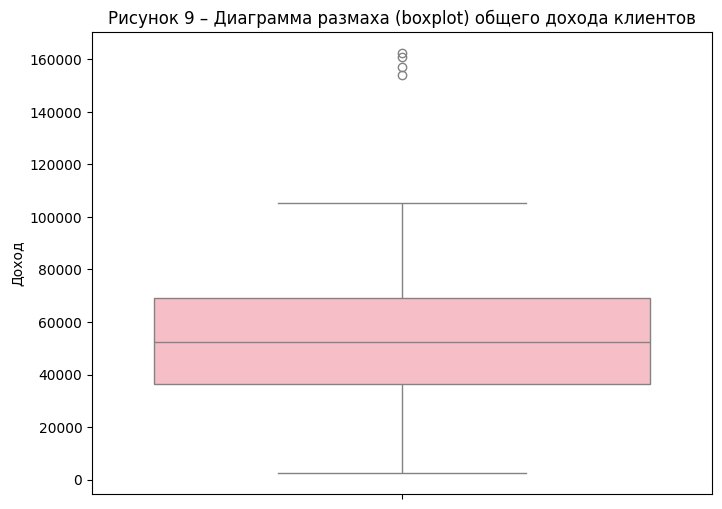

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Income', color='lightpink')
plt.title('Рисунок 9 – Диаграмма размаха (boxplot) общего дохода клиентов')
plt.ylabel('Доход')
plt.show()

На диаграмме размаха  видна медиана дохода, межквартильный размах (25%-75% клиентов). Точки выше верхнего уса представляют собой выбросы – клиентов с аномально высоким доходом, что согласуется с правосторонней асимметрией на гистограмме.

## 8. Создание новой категории и boxplot

В соответствии с методичкой добавляется новая категориальная переменная по числовому признаку Income.

Доход делится на три группы по терцилям:
- Низкий;
- Средний;
- Высокий.
  
После этого строится boxplot исходного числового признака Income отдельно для каждой новой категории.

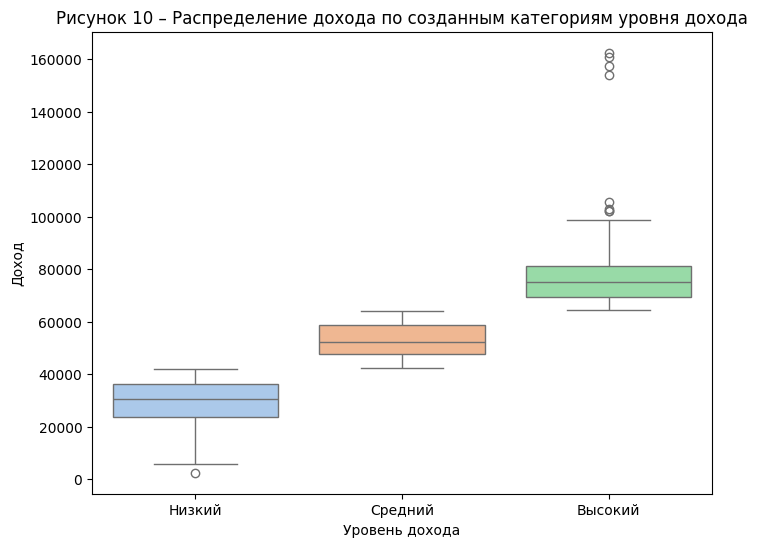

In [65]:
income_tertiles = pd.qcut(df['Income'], q=3, labels=['Низкий', 'Средний', 'Высокий'])
df['Income_Level'] = income_tertiles

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Income_Level', y='Income', hue='Income_Level', legend=False, palette='pastel')
plt.title('Рисунок 10 – Распределение дохода по созданным категориям уровня дохода')
plt.xlabel('Уровень дохода')
plt.ylabel('Доход')
plt.show()

Для анализа распределения клиентов по уровню дохода исходный количественный признак Income был разделён на три равные по числу наблюдений группы — терцили. Для этого использована функция pd.qcut(). Полученные группы соответствуют низкому, среднему и высокому уровню дохода. Такое разбиение позволяет сравнивать клиентов, относящихся к нижней, средней и верхней трети распределения дохода.

## 9. Дополнительные boxplot

Ниже представлены дополнительные диаграммы размаха для других категорий. Используются разные библиотеки построения: matplotlib, seaborn и pandas.

### Boxplot 1. Доход по образованию (библиотека seaborn)

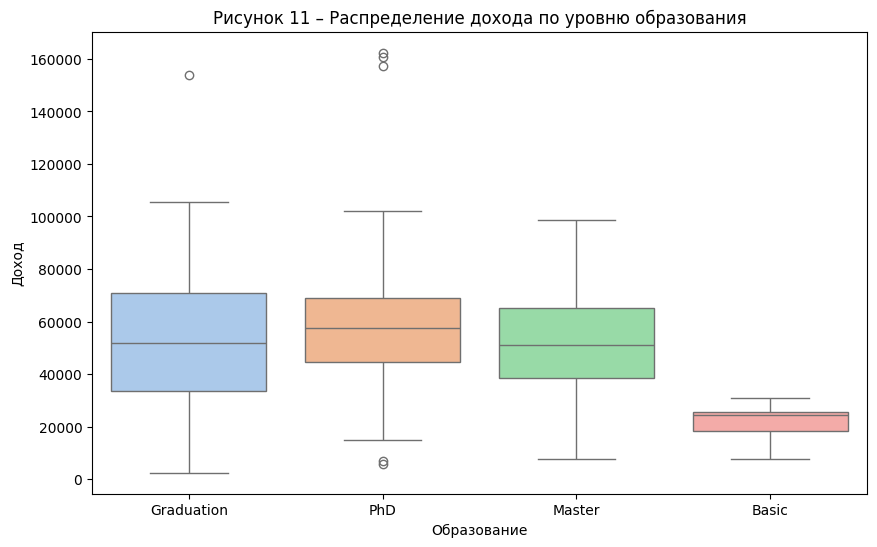

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Education', y='Income', hue='Education', legend=False, palette='pastel')
plt.title('Рисунок 11 – Распределение дохода по уровню образования')
plt.xlabel('Образование')
plt.ylabel('Доход')
plt.show()

Boxplot показывает, что у категории PhD медианный доход расположен выше, чем у Graduation и Master. Для Basic диапазон значений заметно ниже, но эта категория малочисленна. В некоторых группах наблюдаются отдельные высокие значения, которые рассматриваются как потенциальные выбросы.

### Boxplot 2. Доход по семейному статусу (библиотека pandas)

<Figure size 1200x700 with 0 Axes>

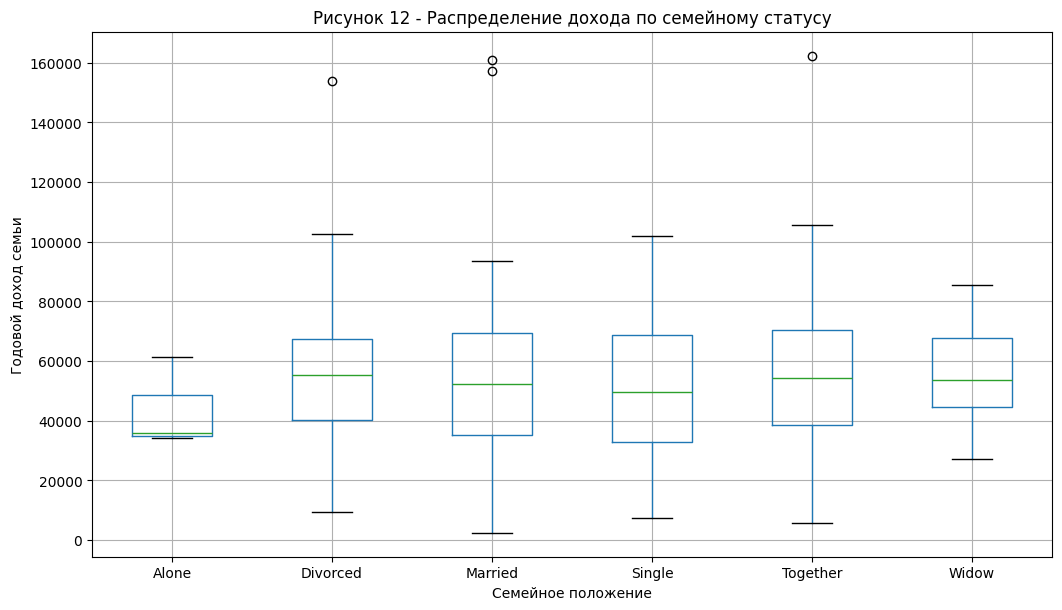

In [58]:
plt.figure(figsize=(12, 7))
df.boxplot(column='Income', by='Marital_Status', figsize=(12, 7), grid=True)
plt.title('Рисунок 12 - Распределение дохода по семейному статусу')
plt.suptitle('')
plt.xlabel('Семейное положение')
plt.ylabel('Годовой доход семьи')
plt.show()

Распределения дохода между семейными статусами заметно перекрываются. Наиболее высокий уровень центральных значений наблюдается у Widow и Divorced и Together, но размер группы Widow существенно меньше, поэтому вывод по ней менее устойчив.

Категория Alone также малочисленна, поэтому её boxplot следует интерпретировать осторожно.

# Дополнительные таблицы для качественной интерпретации

Для итоговой оценки полезно сравнить средние и медианные значения дохода по уровню образования и семейному статусу.

In [61]:
education_summary = df.groupby("Education")["Income"].agg(
    count="count", mean="mean", median="median").sort_values("mean", ascending=False)
marital_summary = df.groupby("Marital_Status")["Income"].agg(
    count="count", mean="mean", median="median").sort_values("mean", ascending=False)

print("Доход по уровню образования:")
display(education_summary.round(2))

print("Доход по семейному статусу:")
display(marital_summary.round(2))

Доход по уровню образования:


,count,mean,median
Education,,,
PhD,190,58227.80,57424.5
Master,147,52443.62,51124.0
Graduation,440,52237.19,51789.5
Basic,15,21235.00,24279.0


Доход по семейному статусу:


,count,mean,median
Marital_Status,,,
Widow,29,55452.45,53653.0
Divorced,85,54568.16,55412.0
Together,193,54491.80,54178.0
Married,307,52889.78,52372.5
Single,175,51105.84,49667.0
Alone,3,43789.00,35860.0


# Выводы

В работе исследован набор данных о клиентах магазина, включающий идентификатор, год рождения, образование, семейное положение, доход, количество детей, дату регистрации и количество покупок. На этапе предварительной обработки были удалены явные дубликаты, унифицированы два неоднородных значения семейного статуса и преобразована дата регистрации.

Исследование распределений показало, что основную часть клиентов составляют представители категории Graduation. Распределение дохода имеет заметный разброс и отдельные высокие значения. При этом в исходном наборе присутствует потенциальная аномалия — год рождения 1899, которая не удалялась без дополнительного обоснования.

Анализ взаимосвязей показал наиболее заметную линейную связь между доходом и количеством детей: корреляция составляет примерно -0.53, то есть связь умеренная отрицательная. Связь между количеством детей и количеством покупок слабая положительная, а связи года рождения с доходом и количества покупок с доходом близки к слабым.

По варианту 14 было установлено, что среди клиентов с детьми более половины имеют уровень образования Graduation. Средний доход отличается между семейными статусами, но группы имеют разную численность, поэтому для малочисленных категорий интерпретацию следует проводить осторожно. Boxplot по образованию также показывает более высокий уровень дохода у клиентов с PhD по сравнению с большинством других образовательных групп.

Исследование показывает, что наиболее заметная количественная зависимость в наборе связана с доходом и количеством детей, а категориальные признаки позволяют дополнительно обнаружить различия в структуре клиентской базы.